<a href="https://colab.research.google.com/github/Neethu-Sathyan/python_eda/blob/my_features_branch/EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Advanced machine learning : EasyVisa
### Problem Statement
* Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

* The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

* OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

* The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval and analyze the data provided and, with the help of a classification model:

    1. Facilitate the process of visa approvals.
    2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.
    
### Data Dictionary
* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* case_status: Flag indicating if the Visa was certified or denied

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Let us start by importing the required libraries


In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

#Libraries to help with data visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# To be used for missing value imputation
from sklearn.impute import SimpleImputer
# To be used for converting categorical into numerical values
from sklearn.preprocessing import LabelEncoder
# Libraries to split data
from sklearn.model_selection import train_test_split

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier


# To get different metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn import metrics
# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

#To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# to support unncessary warnings
import warnings
warnings.filterwarnings("ignore")

### Loading the dataset

In [ ]:
# Load the dataset-Loan Modelling
data=pd.read_csv('/content/drive/MyDrive/GreatLearning/EasyVisa.csv')
# copying data to another variable to avoid any changes to original data
df = data.copy()

### Data Overview

In [ ]:
# sanity checks
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


### Observation
* The dataset contains 12 columns and 25480 rows.
* It has 3 numerical column and 9 catagorical column


In [ ]:
# find the number of rows and column of dataframe
df.shape

(25480, 12)

### Observation
* The dataset contains 25480 rows and 12 columns

In [ ]:
# Get first 5 rows
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


### Observation
* The first 5 rows are shown above

In [ ]:
#Get last 5 rows
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


### Observation
* The last 5 rows of dataset.

In [ ]:
df['case_status'].value_counts()

,count
case_status,
Certified,17018
Denied,8462


### Observation
* There are 17018 applications are got certified and 8462 applications are denied.

In [ ]:
# find the missing values
df.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


### Observation
* There is no missing values

In [ ]:
df.drop(columns=['case_id'],axis=1,inplace=True)
df.duplicated().sum()

np.int64(0)

### Observation
* There is no duplicate values after dropping case_id column

In [ ]:
# Check the statistical summaries of data
df.describe().T


,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


### Observation
* The no_of_employees column has a negative value, which is unrealistic for employee counts.

In [ ]:
# get the negative value in the no_of_employees column
df[df['no_of_employees']<0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.990,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.140,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.940,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.460,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.970,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.320,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.950,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.500,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.610,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.510,Year,Y,Certified


In [ ]:
# Convert all negative values of no_of_employees to absolute value

df['no_of_employees'] = df['no_of_employees'].abs()
print("Minimum value of column no_of_employees",df['no_of_employees'].min())

Minimum value of column no_of_employees 11


### Observation
* The minimum value in the column is no longer negative.

In [ ]:
df.nunique()

,0
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4
full_time_position,2


### Observation
* The categorical columns of 'continent', 'education_of_employee','region_of_employment','unit_of_wage' contains less than 6 unique values.
* Convert these columns into numerical column

### Checking the value counts for each category of categorical variables

In [ ]:
# Making the list of all categorical variables
cat_col=["continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position",
    "case_status"
        ]
# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
----------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
----------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
----------------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
--------

### Observation
* The final status of the visa application shows 17018 certified visa and 8462 visa denied


In [ ]:
# Find the number of dtypes as object
cols = df.select_dtypes(['object'])
cols.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

### Observation
* The columns, continent, has_job_experience, requires_job_training, region_of_employment, full_time_position, case_status have object data types

In [ ]:
# Convert the columns into category data types
for i in cols.columns:
    df[i] = df[i].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


In [ ]:
# convert education_of_employee to ordinal numerical values
encoder = LabelEncoder()
df['education_of_employee']=df['education_of_employee'].map({"High School":0,"Bachelor's":1,"Master's":2,"Doctorate":3})
df['education_of_employee'] = encoder.fit_transform(df['education_of_employee'])
print(df['education_of_employee'])



0        0
1        2
2        1
3        1
4        2
        ..
25475    1
25476    0
25477    2
25478    2
25479    1
Name: education_of_employee, Length: 25480, dtype: int64


In [ ]:
# convert unit_of_wage to ordinal numerical values
df['unit_of_wage']=df['unit_of_wage'].map({'Hour':0,'Week':1,'Month':2,'Year':3})
df['unit_of_wage'] =encoder.fit_transform(df['unit_of_wage'])
print(df['unit_of_wage'])


0        0
1        3
2        3
3        3
4        3
        ..
25475    3
25476    3
25477    3
25478    3
25479    3
Name: unit_of_wage, Length: 25480, dtype: int64


In [ ]:
# convert case_status to numerical values
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})
df['case_status']=encoder.fit_transform(df['case_status'])
print(df['case_status'])

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_status, Length: 25480, dtype: int64


In [ ]:
# convert continent,region_of_employment, to one hot encoding values
df = pd.get_dummies(df, columns=["continent", "region_of_employment"],drop_first=True,dtype=int)
print(df)

       education_of_employee has_job_experience requires_job_training  \
0                          0                  N                     N   
1                          2                  Y                     N   
2                          1                  N                     Y   
3                          1                  N                     N   
4                          2                  Y                     N   
...                      ...                ...                   ...   
25475                      1                  Y                     Y   
25476                      0                  Y                     N   
25477                      2                  Y                     N   
25478                      2                  Y                     Y   
25479                      1                  Y                     N   

       no_of_employees  yr_of_estab  prevailing_wage  unit_of_wage  \
0                14513         2007          592.203 

In [ ]:
# Check the statistical summaries of data
df.describe().T


,count,mean,std,min,25%,50%,75%,max
education_of_employee,25480.000,1.416,0.827,0.000,1.000,1.000,2.000,3.000
no_of_employees,25480.000,5667.089,22877.917,11.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480.000,2.721,0.855,0.000,3.000,3.000,3.000,3.000
case_status,25480.000,0.668,0.471,0.000,0.000,1.000,1.000,1.000
continent_Asia,25480.000,0.662,0.473,0.000,0.000,1.000,1.000,1.000
continent_Europe,25480.000,0.146,0.354,0.000,0.000,0.000,0.000,1.000
continent_North America,25480.000,0.129,0.335,0.000,0.000,0.000,0.000,1.000
continent_Oceania,25480.000,0.008,0.086,0.000,0.000,0.000,0.000,1.000


### Observations
*

### EDA

### Univariate analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

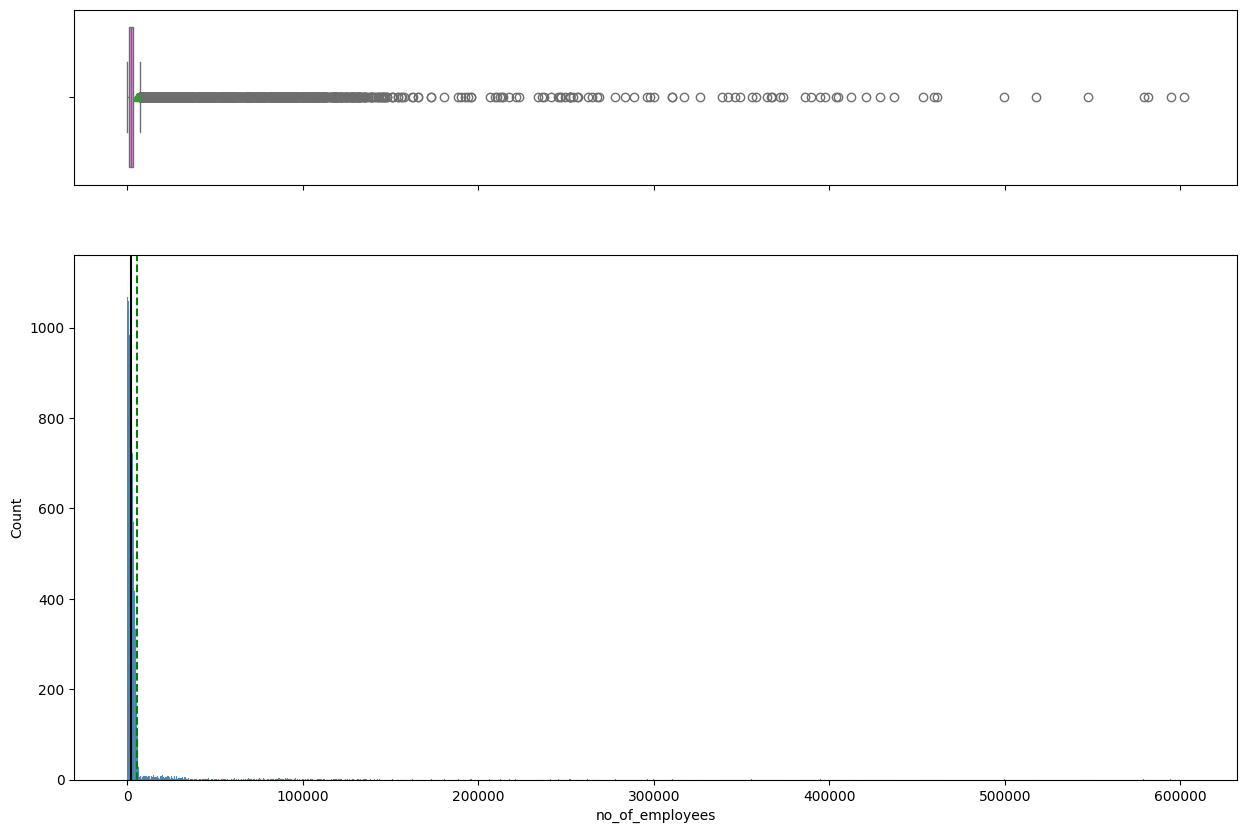

In [ ]:
histogram_boxplot(df, "no_of_employees")

### Observation
* The no_of_employees shows right skewed distribution
* It shows outliers.
* Most companies have a relatively small number of employers

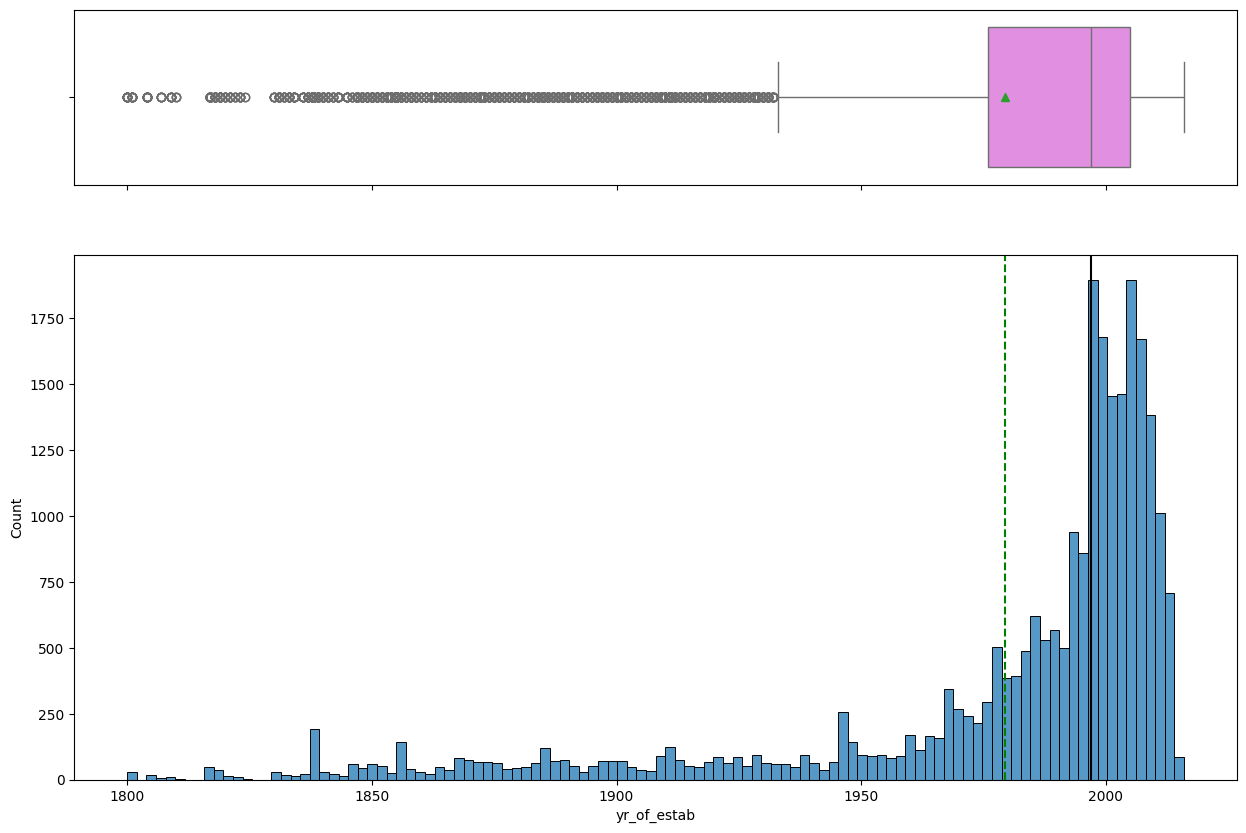

In [ ]:
histogram_boxplot(df, "yr_of_estab")

### Observation
* The year of establishment of the companies shows the left skewed data.
* A few companies are established earlier

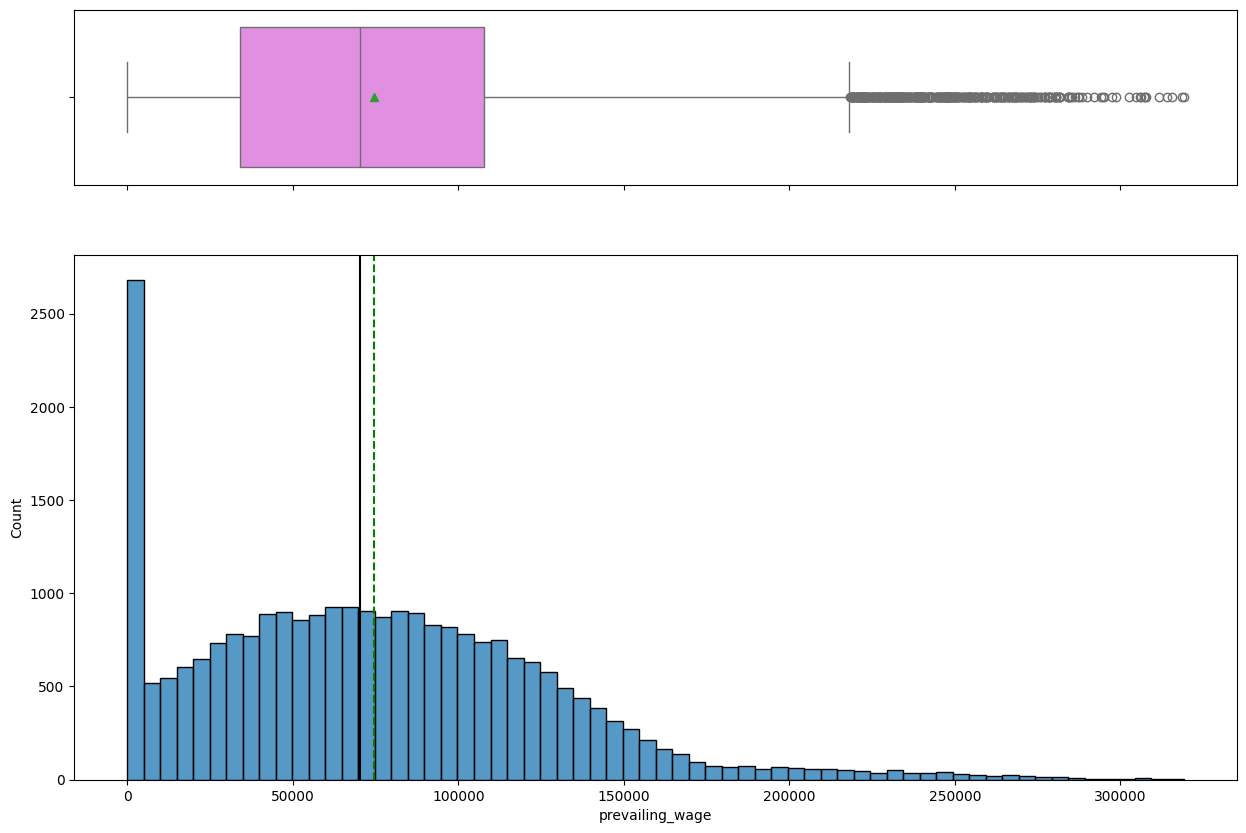

In [ ]:
histogram_boxplot(df, "prevailing_wage")

### Observation
* The prevailing_wage exhibits right skewed data.
* The outliers represent the high paying occupations are less common

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the

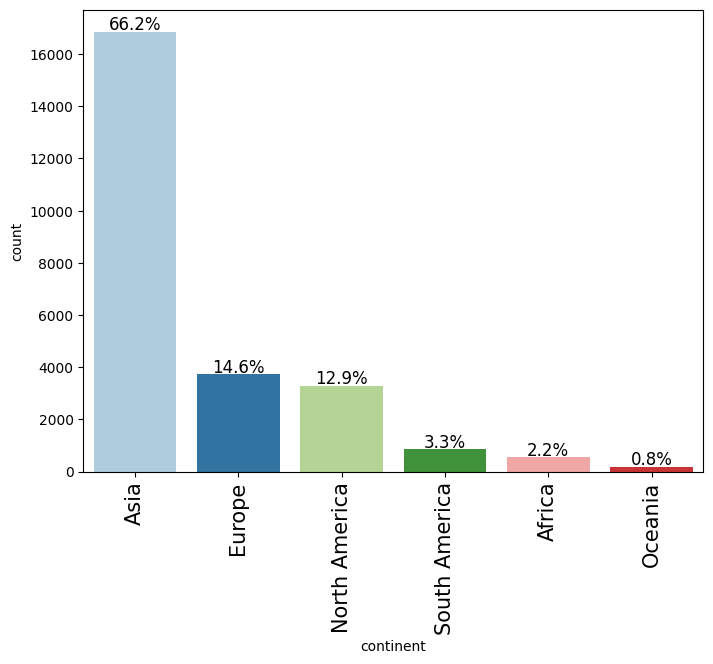

In [ ]:
labeled_barplot(data, "continent", perc=True)

### Observation
* The most the employees(66.2 %) are coming from Asia.


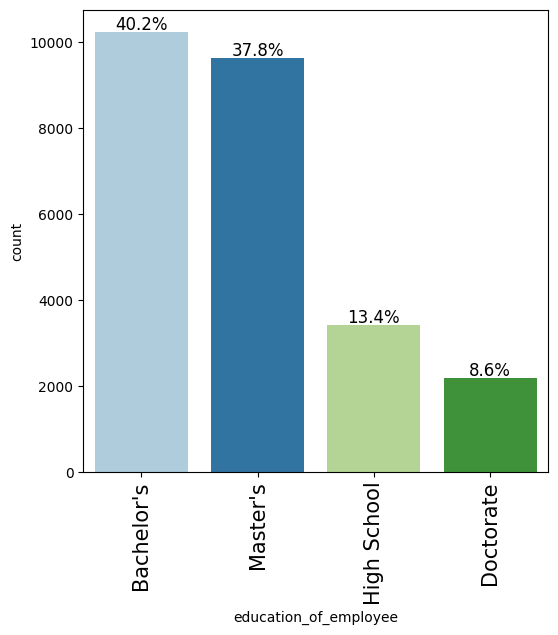

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)

### Observation
* The majority of employees possess a Bachelor's degree(40.2%) while those with a Master's (37.8%)qualification form the next largest group.

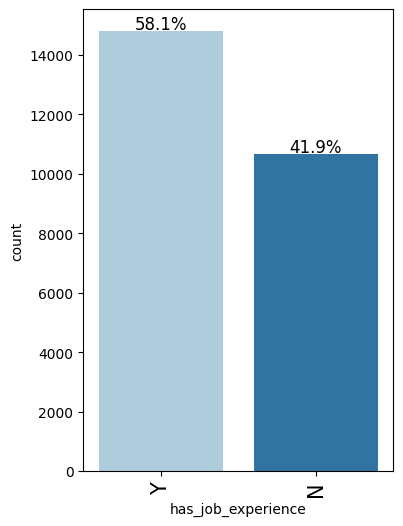

In [ ]:
labeled_barplot(df, "has_job_experience", perc=True)

### Observation
* Most of the employees have job experience

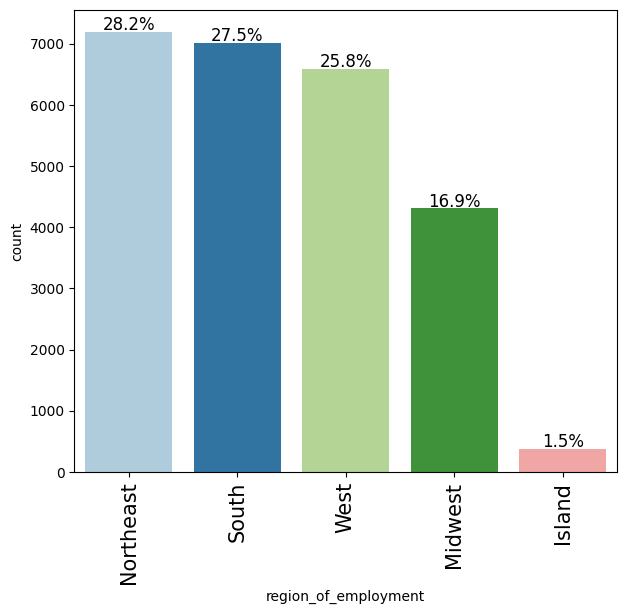

In [ ]:
labeled_barplot(data, "region_of_employment", perc=True)

### Observation
* Most of employees in Northest region(28.2%) and island has less employees(1.5%)

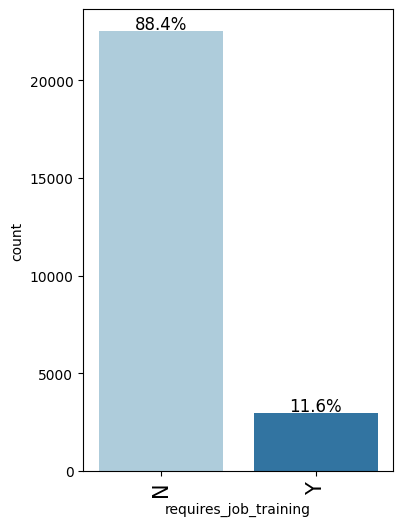

In [ ]:
labeled_barplot(df, "requires_job_training", perc=True)

### Observation
* Most of the employees not required job training

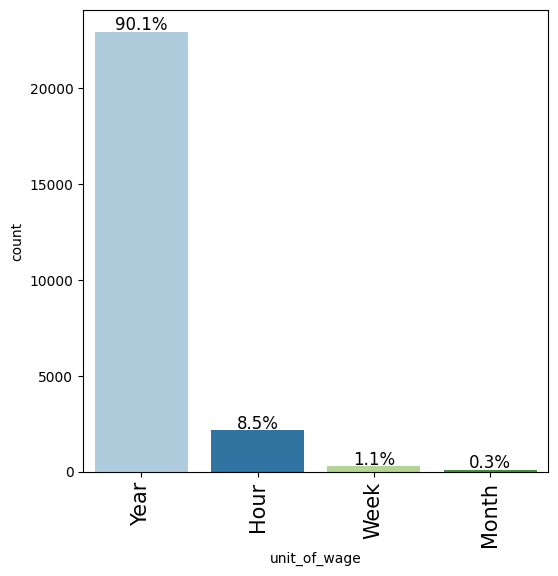

In [ ]:
labeled_barplot(data, "unit_of_wage", perc=True)

### Observation
* Most of the employees have prevailing wage is yearly (90.1%)

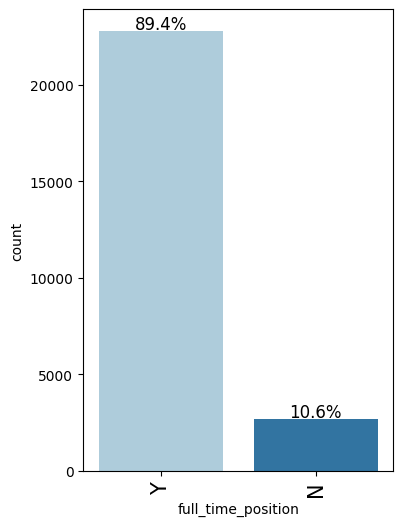

In [ ]:
labeled_barplot(data, "full_time_position", perc=True)

### Observation
* Most of the employees have full time position(89.4%)

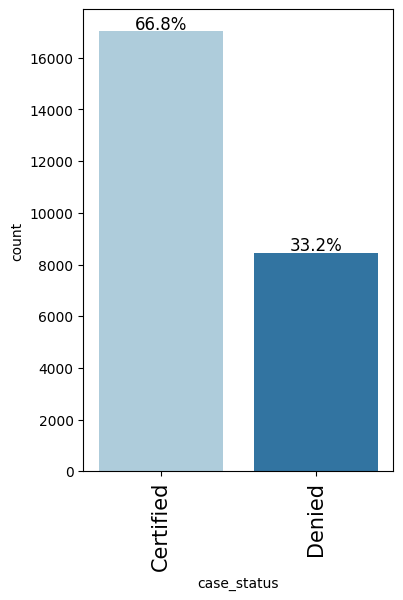

In [ ]:
labeled_barplot(data, "case_status", perc=True)

### Observation
* In case of visa application (66.8 %)is certified visa

### Bivariate Analysis


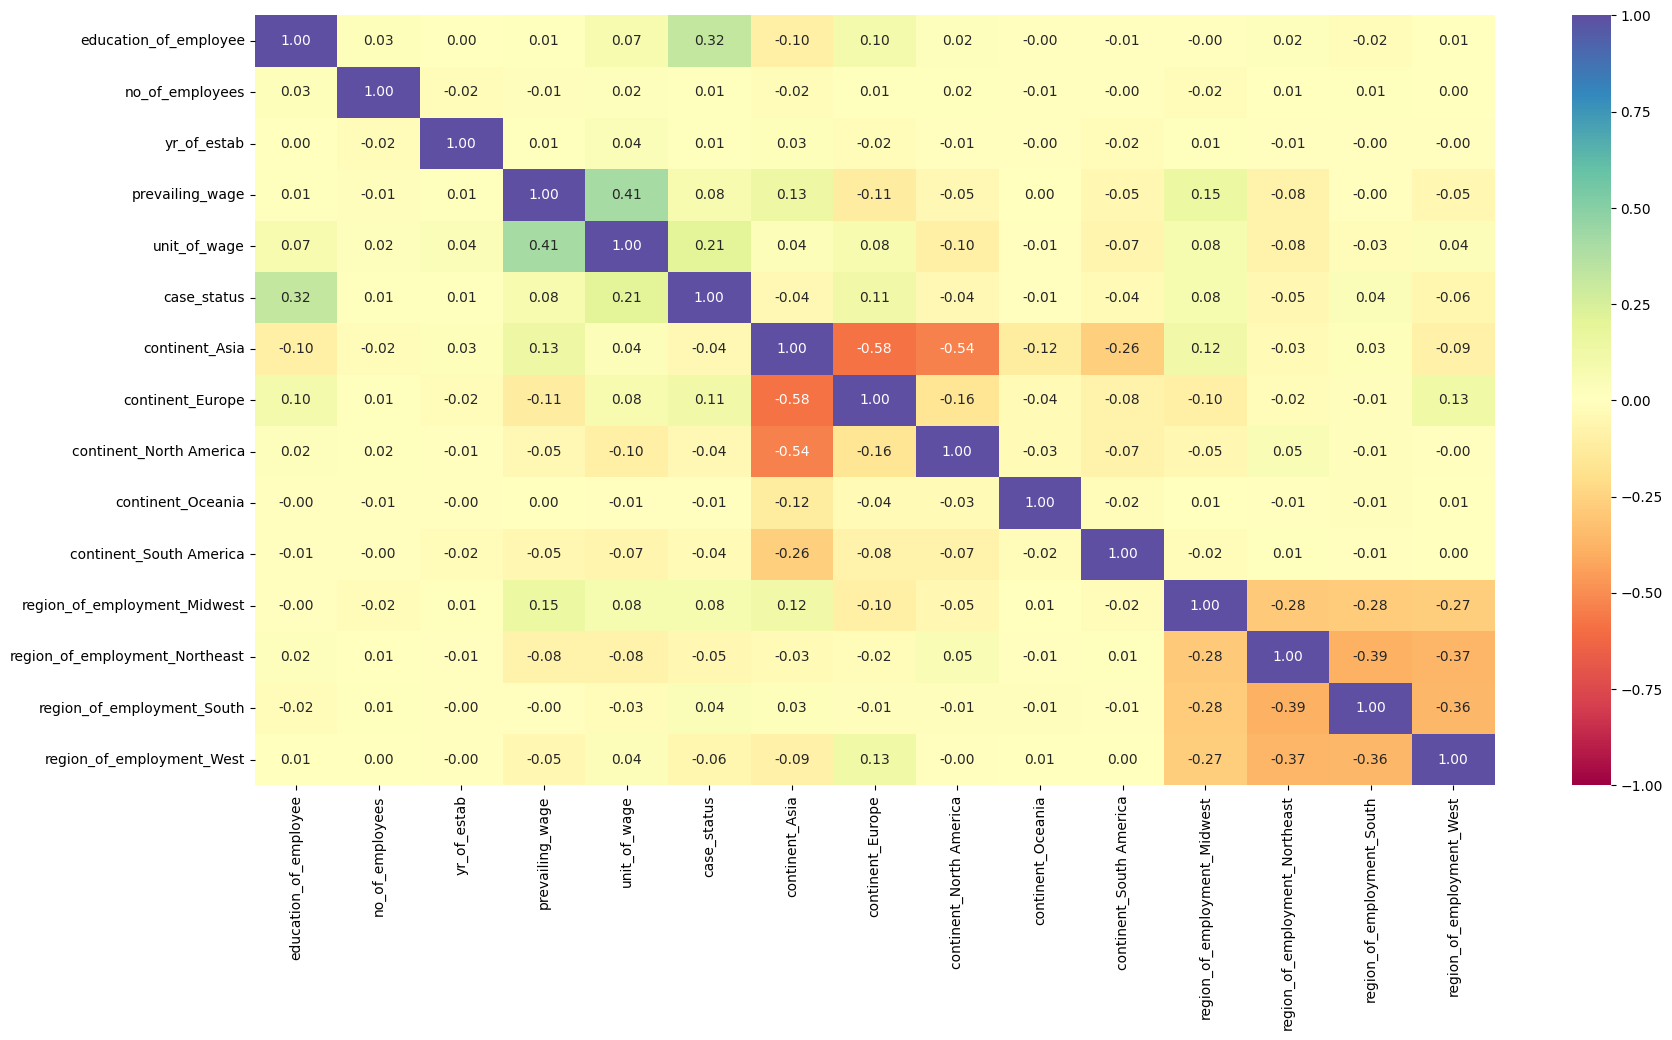

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, vmin=-1, vmax=1, fmt='.2f', cmap="Spectral")
plt.show()

### Observation
* The data shows visa application approval has a positive correlation with education_of_employees,unit_of_wage, continent_Europe,continent_Asia,region_of_employment_Midwest,region_of_employment_South

### Case status vs education of employees

In [ ]:
# Function to create stacked  bar plot
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    # Number of unique predictor
    count = data[predictor].nunique()
    # Sort by the last class in target
    sorter = data[target].value_counts().index[-1]
    # Cross-tab: counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
   # Cross-tab: row-wise % (for stacked bar)
    tab = (pd.crosstab(data[predictor], data[target], normalize='index')*100).sort_values(by=sorter, ascending=False)

    # Plot
    ax = tab.plot(kind='bar', stacked=True, figsize=(count + 5, 6))
    # Format legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title=target)
    plt.ylabel('Percentage (%)')
    plt.xlabel(predictor)
    plt.xticks(rotation=45)

    # Add percentage labels in each segment
    for container in ax.containers:
        ax.bar_label(container,label_type='center',fmt='%.2f%%',               # Format as percentage
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

case_status               0      1    All
education_of_employee                    
All                    8462  17018  25480
1                      3867   6367  10234
0                      2256   1164   3420
2                      2059   7575   9634
3                       280   1912   2192
------------------------------------------------------------------------------------------------------------------------


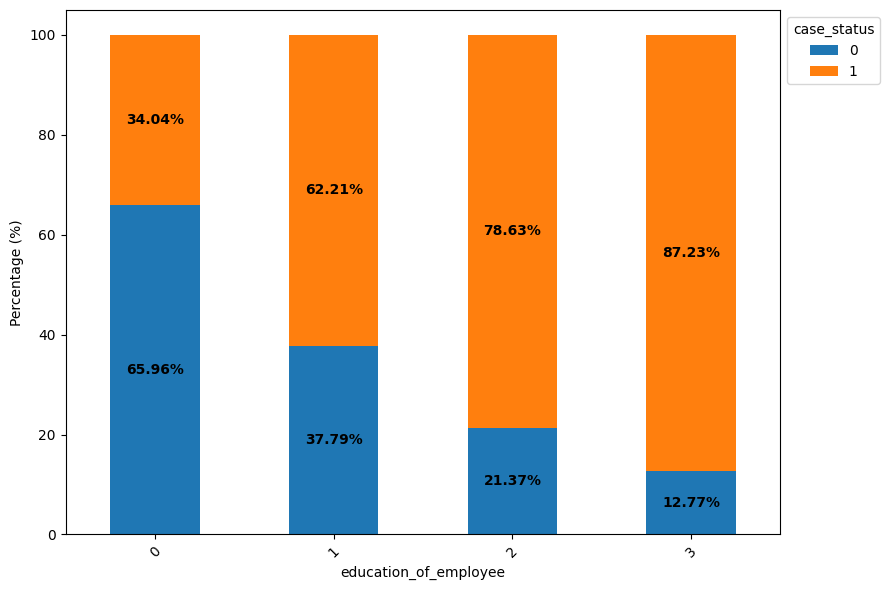

In [ ]:
stacked_barplot(df, "education_of_employee", "case_status")

### Observation
* Compared to employees with other educational backgrounds, people with bachelor's and master's degrees are more likely to have obtained certified visas.
* High school qualified applicants got ~34% approval and doctorate qualified applicants got ~87% approval

In [ ]:
# no of applications with Bachelor's, high school,masters and doctorate certified
df.groupby(['education_of_employee']).case_status.value_counts()

education_of_employee  case_status
0                      0              2256
                       1              1164
1                      1              6367
                       0              3867
2                      1              7575
                       0              2059
3                      1              1912
                       0               280
Name: count, dtype: int64

### Observation
* less no of applicants from doctarate qualification.
* Masters degree qualified applicants has got more approval


case_status          0      1    All
continent_Europe                    
All               8462  17018  25480
0                 7687  14061  21748
1                  775   2957   3732
------------------------------------------------------------------------------------------------------------------------


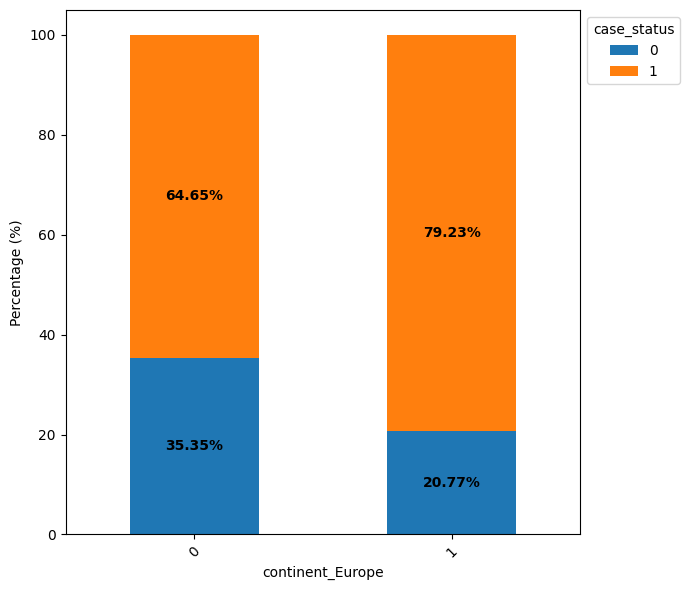

In [ ]:
stacked_barplot(df, "continent_Europe", "case_status")

### Observation
* ~79% of the continent Europe has got visa approval

case_status        0      1    All
continent_Asia                    
All             8462  17018  25480
1               5849  11012  16861
0               2613   6006   8619
------------------------------------------------------------------------------------------------------------------------


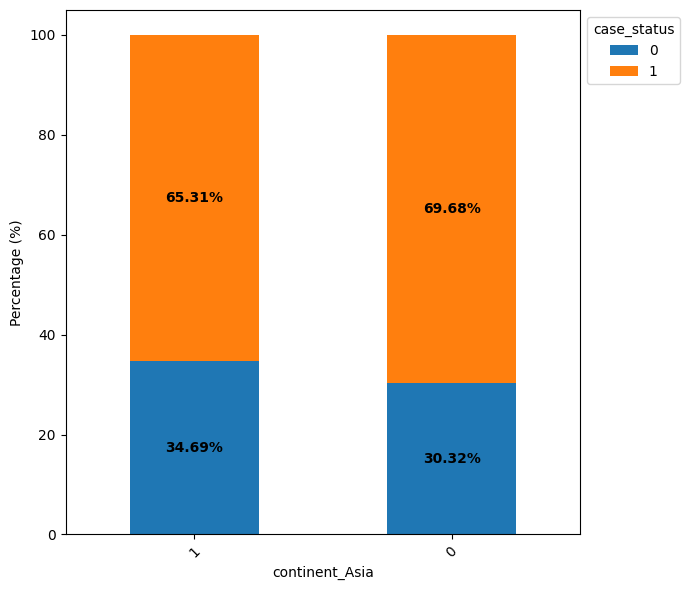

In [ ]:
stacked_barplot(df, "continent_Asia", "case_status")

### Observation
* 65% of the applicants from continent_Asia has got certified visa

case_status                 0      1    All
continent_North America                    
All                      8462  17018  25480
0                        7207  14981  22188
1                        1255   2037   3292
------------------------------------------------------------------------------------------------------------------------


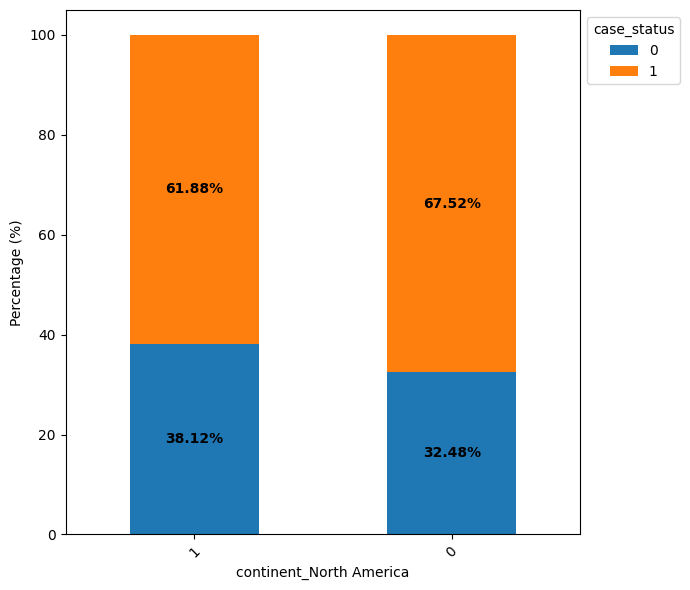

In [ ]:
stacked_barplot(df, "continent_North America", "case_status")

### Observation
* 62% of the applicants from continent_North America has got certified visa

case_status                 0      1    All
continent_South America                    
All                      8462  17018  25480
0                        8103  16525  24628
1                         359    493    852
------------------------------------------------------------------------------------------------------------------------


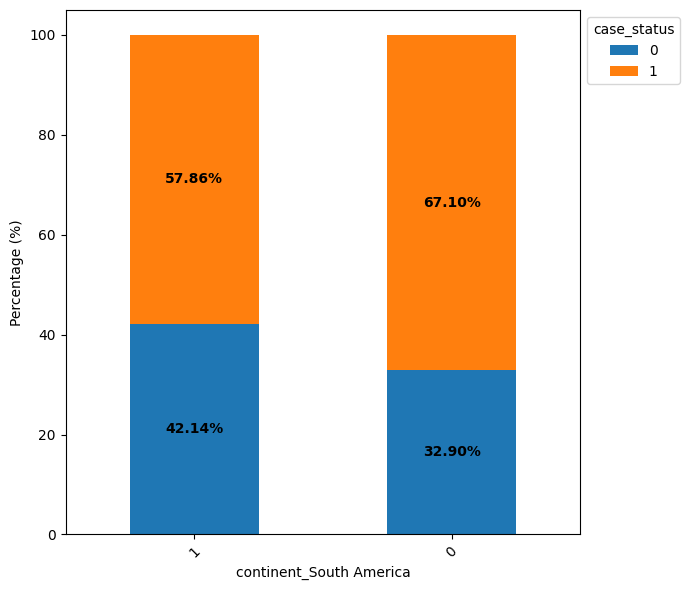

In [ ]:
stacked_barplot(df, "continent_South America", "case_status")

### Observation
* 58% of the applicants from continent_South America has got certified visa

case_status           0      1    All
continent_Oceania                    
All                8462  17018  25480
0                  8392  16896  25288
1                    70    122    192
------------------------------------------------------------------------------------------------------------------------


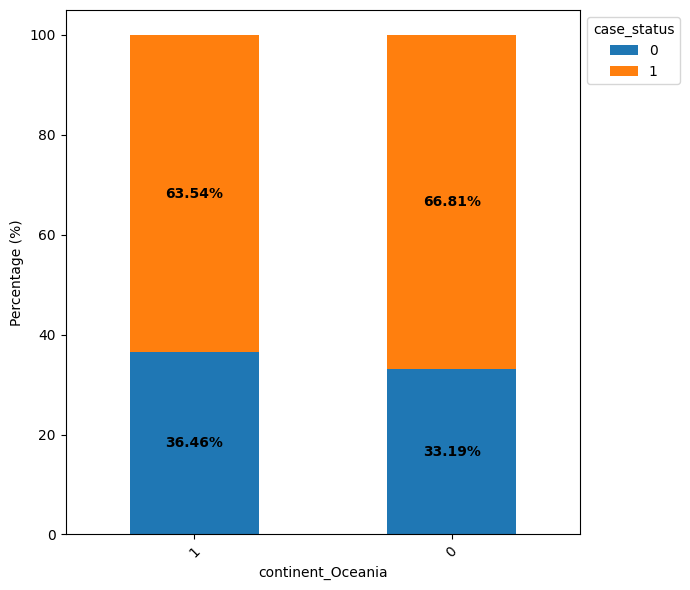

In [ ]:
stacked_barplot(df, "continent_Oceania", "case_status")

### Observation
* 64% of the applicants from continent_Oceania has got certified visa

case_status                      0      1    All
region_of_employment_Midwest                    
All                           8462  17018  25480
0                             7408  13765  21173
1                             1054   3253   4307
------------------------------------------------------------------------------------------------------------------------


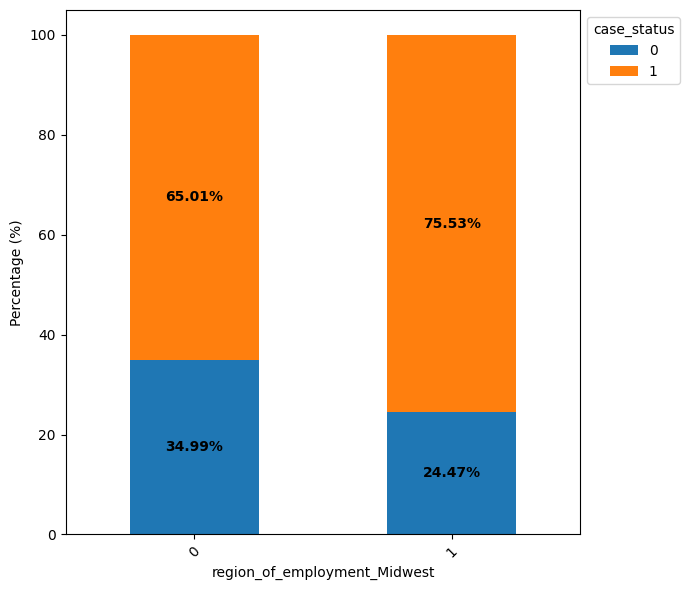

In [ ]:
stacked_barplot(df, "region_of_employment_Midwest", "case_status")

### Observation
* 76% of the applicants from region_of_employment_Midwest has got certified visa

case_status                        0      1    All
region_of_employment_Northeast                    
All                             8462  17018  25480
0                               5793  12492  18285
1                               2669   4526   7195
------------------------------------------------------------------------------------------------------------------------


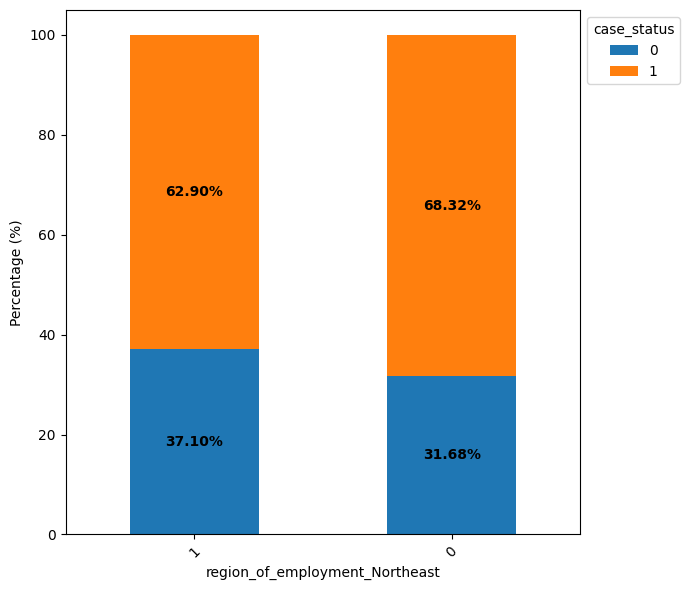

In [ ]:
stacked_barplot(df, "region_of_employment_Northeast", "case_status")

### Observation
* 63% of the applicants from region_of_employment_Northeast has got certified visa:

case_status                    0      1    All
region_of_employment_South                    
All                         8462  17018  25480
0                           6358  12105  18463
1                           2104   4913   7017
------------------------------------------------------------------------------------------------------------------------


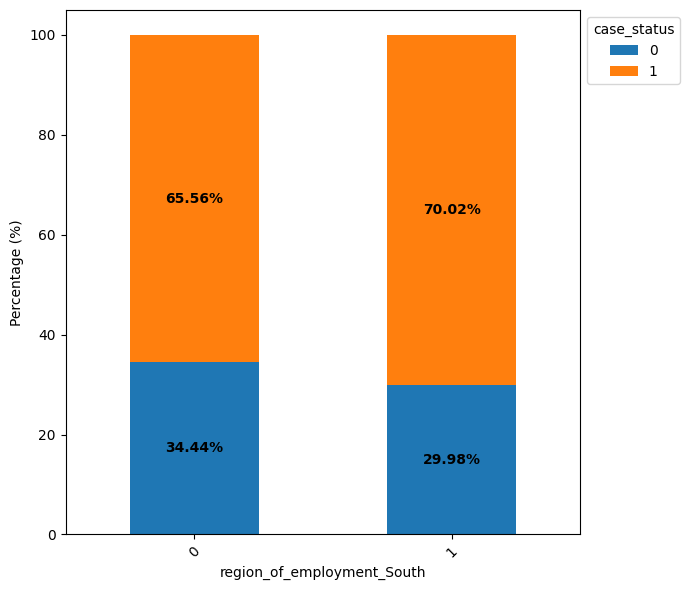

In [ ]:
stacked_barplot(df, "region_of_employment_South", "case_status")

### Observation
* 70% of the applicants from region_of_employment_South has got certified visa

case_status                   0      1    All
region_of_employment_West                    
All                        8462  17018  25480
0                          5976  12918  18894
1                          2486   4100   6586
------------------------------------------------------------------------------------------------------------------------


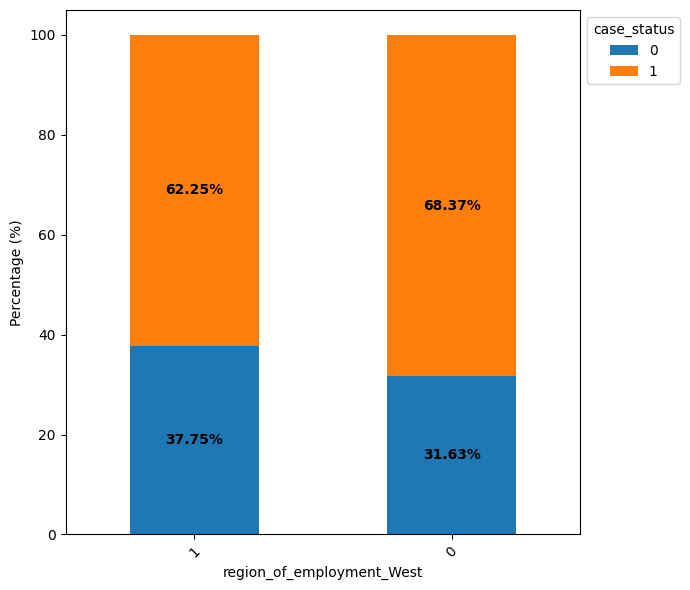

In [ ]:
stacked_barplot(df, "region_of_employment_West", "case_status")

### Observation
* 62% of the applicants from region_of_employment_West has got certified visa

Case status Vs Unit_of_wage

case_status               0      1    All
education_of_employee                    
All                    8462  17018  25480
1                      3867   6367  10234
0                      2256   1164   3420
2                      2059   7575   9634
3                       280   1912   2192
------------------------------------------------------------------------------------------------------------------------


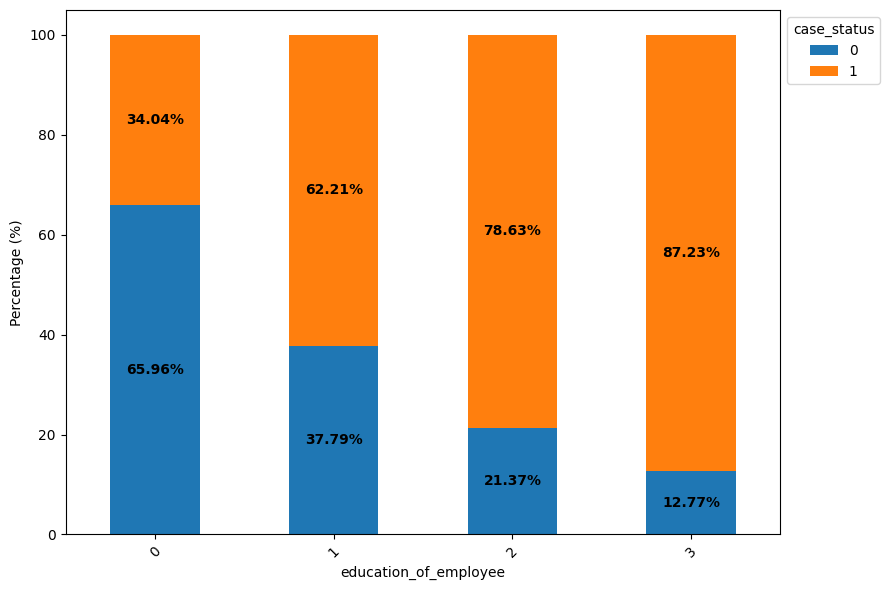

In [ ]:
stacked_barplot(df, "education_of_employee", "case_status")

### Observation
* 87% of the applicants with master degree has got visa certified
* 34% of the applicants with high school education has got visa certified

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


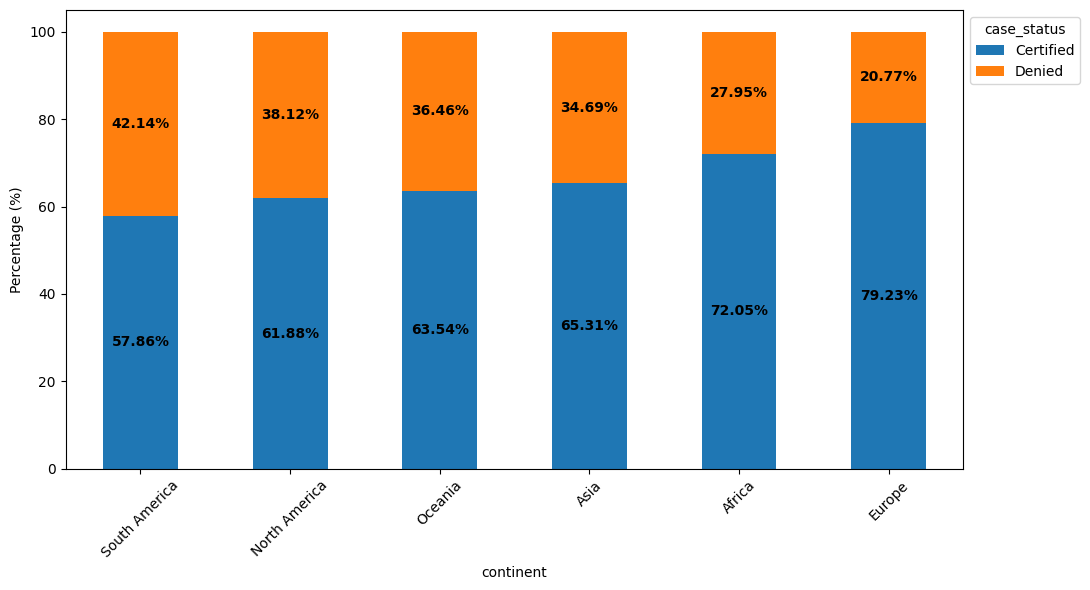

In [ ]:
stacked_barplot(data, "continent", "case_status")

### Observation
* ~79% of Applicants from Europe has got visa certified
* ~58% of the applicants from South America has got visa certified.

case_status            0      1    All
has_job_experience                    
All                 8462  17018  25480
N                   4684   5994  10678
Y                   3778  11024  14802
------------------------------------------------------------------------------------------------------------------------


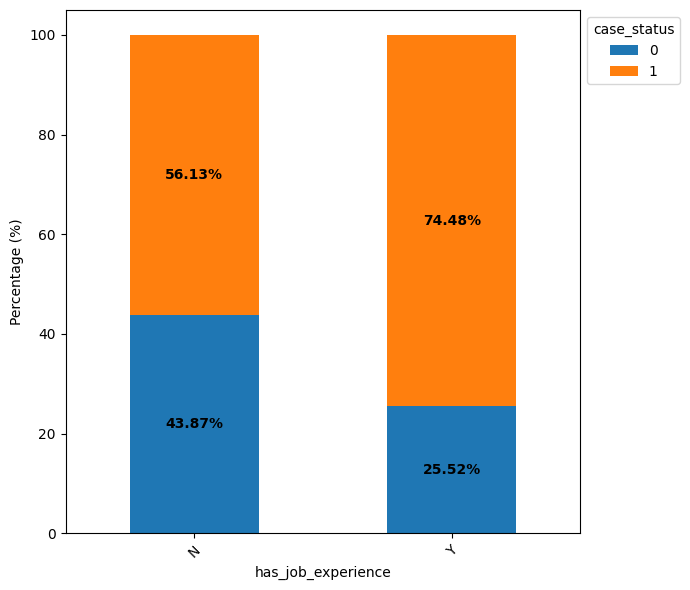

In [ ]:
stacked_barplot(df, "has_job_experience", "case_status")

### Observation
* 74% of the applicants with job experience got certified

case_status            0      1    All
full_time_position                    
All                 8462  17018  25480
Y                   7610  15163  22773
N                    852   1855   2707
------------------------------------------------------------------------------------------------------------------------


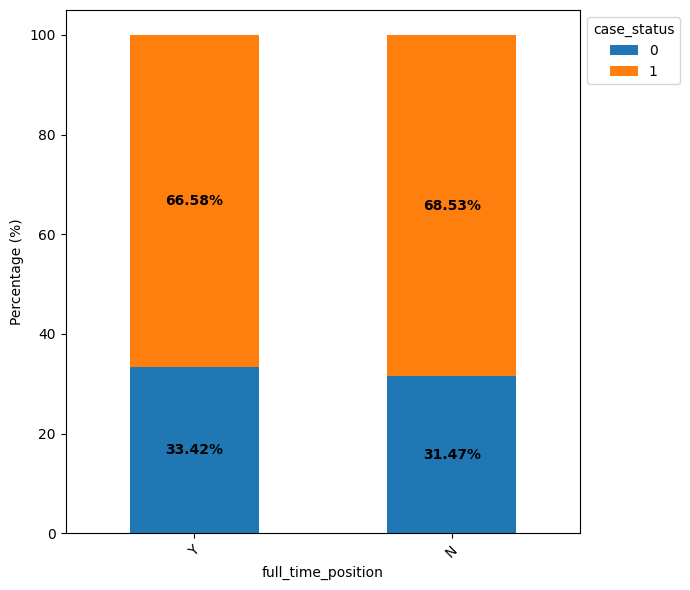

In [ ]:
stacked_barplot(df, "full_time_position", "case_status")

### Observation
* 66.58% of the applicants with full time job  got certified

case_status      0      1    All
unit_of_wage                    
All           8462  17018  25480
3             6915  16047  22962
0             1410    747   2157
1              103    169    272
2               34     55     89
------------------------------------------------------------------------------------------------------------------------


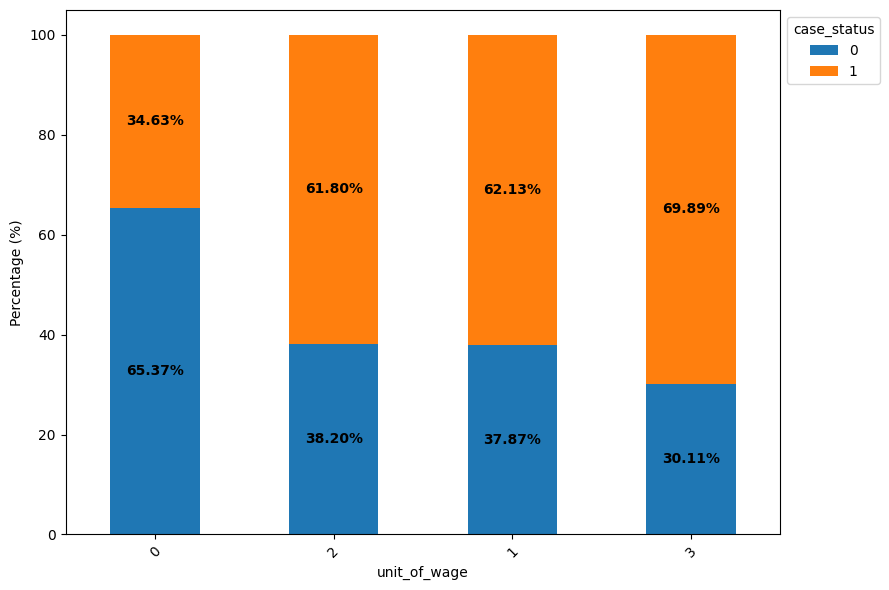

In [ ]:
stacked_barplot(df, "unit_of_wage", "case_status")

### Observation
* 69.89% of the applicants with yearly unit of wage  got certified

### Observation
* 66.58% of the applicants with full time job  got certified

case_status               0      1    All
requires_job_training                    
All                    8462  17018  25480
N                      7513  15012  22525
Y                       949   2006   2955
------------------------------------------------------------------------------------------------------------------------


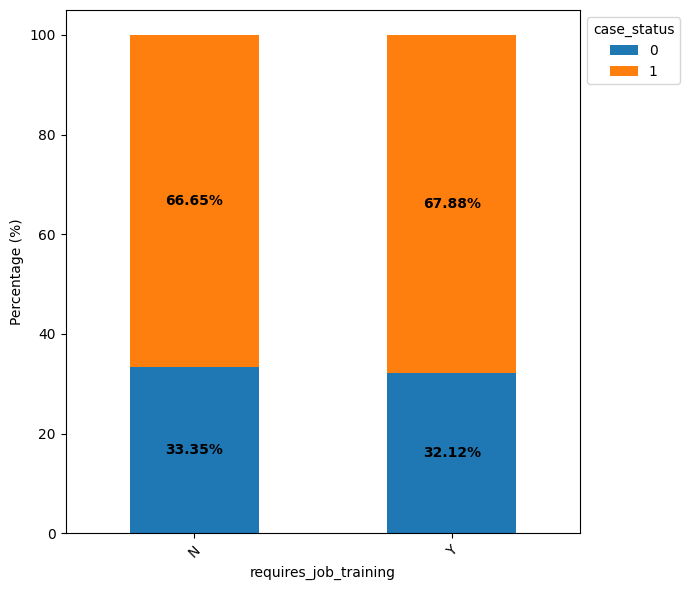

In [ ]:
stacked_barplot(df, "requires_job_training", "case_status")

### Observation
* 67.88% of the applicants with job training required got certified

### Data Preprocessing

In [ ]:
# preparing input 'x' and target 'y'
X=df.drop(['case_status'],axis=1)
y=df['case_status']

In [ ]:
# Splitting data into training, validation and test sets:
# first split data into 2 parts, temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 17) (5096, 17) (5096, 17)


### Generate Dummy values for categorical columns

In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

### Model building

## Model evaluation criterion

### We will be using Precision as a metric for our model performance because OFLC faces 2 types of issues


1. Visa approval of non skilled applicants
2.  Visa rejection of skilled applicants


### Which loss is greater?
* visa approval of non skilled applicants incure higher cost to the company.
Hence false positives has to avoided.
* Visa approval of skilled applicants rejection incure loss of experts to the company. Hence false negatives has to avoided.
* By considering both the condition precision metric and recall metric has to be taken for performance evaluation





### How to reduce the loss?

* OFLC wants to precision to be maximised so that it will reduce the number of false positives
* OFLC wants to recall to be maximised so that it will reduce the number of false negatives


### Initial Model Building

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))



print("\n" "Validation Performance Precision parameters:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = precision_score(y_val, model.predict(X_val))

    print("{}: {}".format(name, scores))

print("\n" "Validation Performance Recall parameters:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))

    print("{}: {}".format(name, scores))


Validation Performance Precision parameters:

Bagging: 0.7792475014697237
Random forest: 0.7732463295269169
GBM: 0.7816605359957961
Adaboost: 0.7629233511586453
Xgboost: 0.7672209026128266
dtree: 0.7533883323512081

Validation Performance Recall parameters:

Bagging: 0.7787896592244419
Random forest: 0.8354876615746181
GBM: 0.8739717978848414
Adaboost: 0.8801410105757932
Xgboost: 0.8539952996474736
dtree: 0.7511750881316098


In [ ]:
print("\nTraining and Validation of precision Performance Difference on Original Data:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = precision_score(y_train, model.predict(X_train))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))

print("\nTraining and Validation of recall Performance Difference on Original Data:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation of precision Performance Difference on Original Data:

Bagging: Training Score: 0.9916, Validation Score: 0.7792, Difference: 0.2124
Random forest: Training Score: 1.0000, Validation Score: 0.7732, Difference: 0.2268
GBM: Training Score: 0.7829, Validation Score: 0.7817, Difference: 0.0012
Adaboost: Training Score: 0.7608, Validation Score: 0.7629, Difference: -0.0022
Xgboost: Training Score: 0.8545, Validation Score: 0.7672, Difference: 0.0873
dtree: Training Score: 1.0000, Validation Score: 0.7534, Difference: 0.2466

Training and Validation of recall Performance Difference on Original Data:

Bagging: Training Score: 0.9853, Validation Score: 0.7788, Difference: 0.2065
Random forest: Training Score: 1.0000, Validation Score: 0.8355, Difference: 0.1645
GBM: Training Score: 0.8797, Validation Score: 0.8740, Difference: 0.0058
Adaboost: Training Score: 0.8880, Validation Score: 0.8801, Difference: 0.0078
Xgboost: Training Score: 0.9423, Validation Score: 0.8540,

### Observation
* **In case of precision**,
     The GBM shows best performance followed by Adaboosting to the higher training and validation metric score  and less metric score difference(Minimal overfitting)
* **In case of Recall**,
      The Adaboost shows best performance followed by GBM due to the higher training and validation metric score eventhough slight difference in score
      (Minimal overfitting)

### Model building Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 17)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance based on precision:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = precision_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance based on precision:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

print("\n" "Training Performance based on recall:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance based on recall:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance based on precision:

Bagging: 0.9917650560571485
Random forest: 0.9999020568070519
GBM: 0.7682368775235532
Adaboost: 0.769175991861648
dtree: 1.0

Validation Performance based on precision:

Bagging: 0.7810173697270472
Random forest: 0.7796658986175116
GBM: 0.7925905136121246
Adaboost: 0.7941176470588235
dtree: 0.7523335407591786

Training Performance based on recall:

Bagging: 0.9790401567091087
Random forest: 0.9999020568070519
GBM: 0.8385896180215475
Adaboost: 0.7405484818805093
dtree: 1.0

Validation Performance based on recall:

Bagging: 0.7397179788484136
Random forest: 0.79524089306698
GBM: 0.8296122209165687
Adaboost: 0.7376615746180963
dtree: 0.7103407755581669


### Observation after oversampling
* In case of precision metric, after over sampling Adaboost has better performance
* In case of recall metric, after oversampling GBM has better performance

In [ ]:
print("\nTraining and Validation Performance Difference on OverSampled Data based on precision:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = precision_score(y_train_over, model.predict(X_train_over))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))
print("\nTraining and Validation Performance Difference on OverSampled Data based on recall:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference on OverSampled Data based on precision:

Bagging: Training Score: 0.9918, Validation Score: 0.7810, Difference: 0.2107
Random forest: Training Score: 0.9999, Validation Score: 0.7797, Difference: 0.2202
GBM: Training Score: 0.7682, Validation Score: 0.7926, Difference: -0.0244
Adaboost: Training Score: 0.7692, Validation Score: 0.7941, Difference: -0.0249
dtree: Training Score: 1.0000, Validation Score: 0.7523, Difference: 0.2477

Training and Validation Performance Difference on OverSampled Data based on recall:

Bagging: Training Score: 0.9790, Validation Score: 0.7397, Difference: 0.2393
Random forest: Training Score: 0.9999, Validation Score: 0.7952, Difference: 0.2047
GBM: Training Score: 0.8386, Validation Score: 0.8296, Difference: 0.0090
Adaboost: Training Score: 0.7405, Validation Score: 0.7377, Difference: 0.0029
dtree: Training Score: 1.0000, Validation Score: 0.7103, Difference: 0.2897


### Observation After oversampling by considering training, validation and minimal overfitting
* based on precision metric Adaboosting has better performance
* based on recall metric tric GBM has better performance


### Model Building - Under sampled data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 17)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
print("\n" "Training Performance based on precision:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = precision_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance based on precision:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

print("\n" "Training Performance based on recall:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance based on recall:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance based on precision:

Bagging: 0.991125453812021
Random forest: 1.0
GBM: 0.71
Adaboost: 0.6830238726790451
dtree: 1.0

Validation Performance based on precision:

Bagging: 0.8257097791798107
Random forest: 0.8222301389383684
GBM: 0.8284671532846716
Adaboost: 0.8159675236806495
dtree: 0.7709235209235209

Training Performance based on recall:

Bagging: 0.967703820401733
Random forest: 1.0
GBM: 0.7550216620716818
Adaboost: 0.7099251673887357
dtree: 1.0

Validation Performance based on recall:

Bagging: 0.6151586368977673
Random forest: 0.6780258519388954
GBM: 0.7335487661574618
Adaboost: 0.7085781433607521
dtree: 0.6277908343125734


In [ ]:
print("\nTraining and Validation Performance Difference based on precision:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = precision_score(y_train_un, model.predict(X_train_un))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))
print("\nTraining and Validation Performance Difference based on recall:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference based on precision:

Bagging: Training Score: 0.9911, Validation Score: 0.8257, Difference: 0.1654
Random forest: Training Score: 1.0000, Validation Score: 0.8222, Difference: 0.1778
GBM: Training Score: 0.7100, Validation Score: 0.8285, Difference: -0.1185
Adaboost: Training Score: 0.6830, Validation Score: 0.8160, Difference: -0.1329
dtree: Training Score: 1.0000, Validation Score: 0.7709, Difference: 0.2291

Training and Validation Performance Difference based on recall:

Bagging: Training Score: 0.9677, Validation Score: 0.6152, Difference: 0.3525
Random forest: Training Score: 1.0000, Validation Score: 0.6780, Difference: 0.3220
GBM: Training Score: 0.7550, Validation Score: 0.7335, Difference: 0.0215
Adaboost: Training Score: 0.7099, Validation Score: 0.7086, Difference: 0.0013
dtree: Training Score: 1.0000, Validation Score: 0.6278, Difference: 0.3722


### Observation
* GBM is the best performer based on the precision(considering minimal overfitting)
* Adaboost has best performance based on recall(consider minimal overfitting)

### Model Building and Comparison on original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "precision"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))
print("\n" "Validation Performance based on precision:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = precision_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))
print("\n" "Validation Performance based on reall:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.03094656430285
Random forest: 77.11158544778247
GBM: 77.67713351371229
Adaboost: 75.97117594243477
Xgboost: 76.92252431247894
dtree: 74.44872903720827

Validation Performance based on precision:

Bagging: 0.7792475014697237
Random forest: 0.7732463295269169
GBM: 0.7816605359957961
Adaboost: 0.7629233511586453
Xgboost: 0.7672209026128266
dtree: 0.7533883323512081

Cross-Validation Performance:

Bagging: 77.66895200783546
Random forest: 84.37806072477963
GBM: 87.3947110675808
Adaboost: 88.61900097943195
Xgboost: 85.48481880509303
dtree: 73.49657198824681

Validation Performance based on reall:

Bagging: 0.7787896592244419
Random forest: 0.8354876615746181
GBM: 0.8739717978848414
Adaboost: 0.8801410105757932
Xgboost: 0.8539952996474736
dtree: 0.7511750881316098


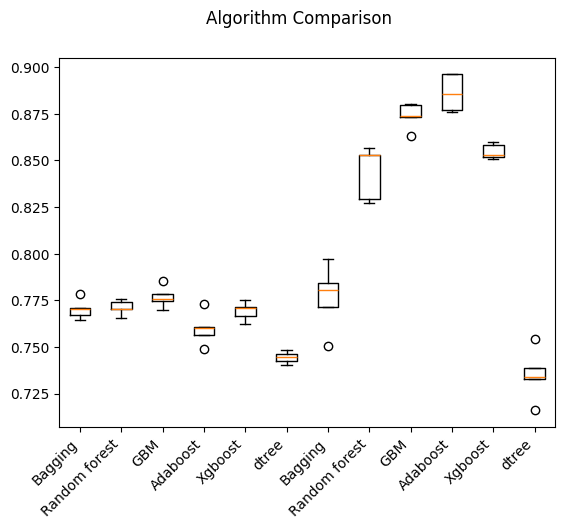

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names,rotation=45,ha='right')

plt.show()

### Observation
* GBM has best performance based on precision metrics
* Adaboost has best perfomance based on recall metrics

### Hyperparameter Tuning

###  Define built in functions to calculate different metrics and confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### AdaBoost

### GridSearchCV

In [ ]:
# Creating pipeline
dtc=DecisionTreeClassifier()
#Initialize AdaBoost
model=AdaBoostClassifier(estimator=dtc, random_state=1) #taking default parameters with decision tree as base estimator

# set parameters
param_grid = {
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__max_depth': [3, 4, 5],
    'estimator__min_samples_split': [2, 7, 10]
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)



# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'estimator__criterion': 'gini', 'estimator__max_depth': 3, 'estimator__min_samples_split': 2} 
Score: 0.8703232125367286


In [ ]:
# Creating new pipeline with best parameters
# base estimator with best parameters
dtc = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=2,
    random_state=1
)

# Pass the best parameter to AdaBoost
model_tuned1 = AdaBoostClassifier(
    estimator=dtc,
    random_state=1
)


# Fit the model on training data
model_tuned1.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   random_state=1)

In [ ]:
# Calculating different metrics on train set
adaboost_grid_train = model_performance_classification_sklearn(
    model_tuned1, X_train, y_train
)
print("Training performance:")
adaboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.746,0.862,0.781,0.819


In [ ]:
# Calculating different metrics on validation set
adaboost_grid_val = model_performance_classification_sklearn(model_tuned1, X_val, y_val)
print("Validation performance:")
adaboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.746,0.857,0.783,0.818


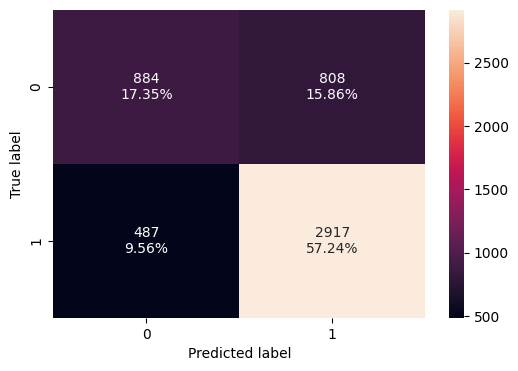

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(model_tuned1, X_val, y_val)

* The validation recall has almost similar performance to the validation recall on model with default parameter
* The validation recall is ~86%

### RandomizedSearchCV

In [ ]:
# Creating pipeline
dtc=DecisionTreeClassifier()
# Create AdaBoost model using that base estimator
model=AdaBoostClassifier(estimator=dtc, random_state=1) #taking default parameters with decision tree as base estimator

# set parameters
param_grid = {
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__max_depth': [3, 4, 5],
    'estimator__min_samples_split': [2, 7, 10]
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'estimator__min_samples_split': 2, 'estimator__max_depth': 3, 'estimator__criterion': 'gini'} with CV score=0.8703232125367286:


* The best parameter got from Randomized search is same as that got from GridSearch.

### GBM

### GridSearchCV

In [ ]:
#defining model
model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse','entropy'],
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1, verbose= 2)

#Fitting parameters in GridSeachCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters are {'criterion': 'squared_error', 'max_features': 1, 'n_estimators': 100, 'subsample': 0.9} with CV score=0.9065621939275221:


In [ ]:
# building model with best parameters
gb_tuned1=GradientBoostingClassifier(
    random_state=1,
    n_estimators=100,
    subsample=1,
    criterion="squared_error",
    max_depth=1,
)
# Fit the model on training data
gb_tuned1.fit(X_train,y_train)




GradientBoostingClassifier(criterion='squared_error', max_depth=1,
                           random_state=1, subsample=1)

In [ ]:
# Calculating different metrics on train set
gboost_grid_train = model_performance_classification_sklearn(
    gb_tuned1, X_train, y_train
)
print("Training performance:")
gboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.726,0.922,0.735,0.818


In [ ]:
# Calculating different metrics on validation set
gboost_grid_val = model_performance_classification_sklearn(gb_tuned1, X_val, y_val)
print("Validation performance:")
gboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.728,0.918,0.738,0.818


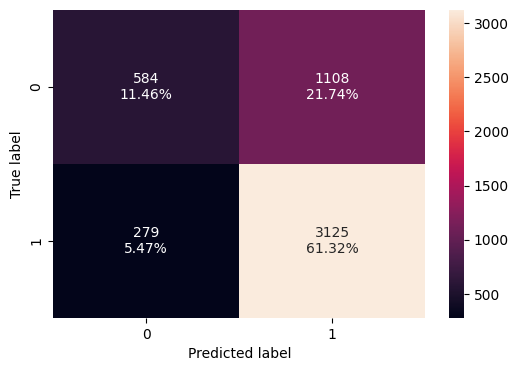

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(gb_tuned1, X_val, y_val)

* Recall has increased to ~92% as compared to the tuned Adaboost
*

### RandomizedSearchCV

In [ ]:
#defining model
model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse','entropy'],
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
gb_tuned2 = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
gb_tuned2.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(gb_tuned2.best_params_,gb_tuned2.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 100, 'max_features': 1, 'criterion': 'friedman_mse'} with CV score=0.9045053868756121:


In [ ]:
gb_tuned2 = GradientBoostingClassifier(
    random_state=1,
    n_estimators=100,
    subsample=0.8,
    criterion="friedman_mse",
    max_features=1,
)

# Fit the model on training data
gb_tuned2.fit(X_train, y_train)

GradientBoostingClassifier(max_features=1, random_state=1, subsample=0.8)

In [ ]:
# Calculating different metrics on train set
gboost_random_train = model_performance_classification_sklearn(
    gb_tuned2, X_train, y_train
)
print("Training performance:")
gboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.737,0.928,0.743,0.825


In [ ]:
# Calculating different metrics on validation set
gboost_random_val = model_performance_classification_sklearn(gb_tuned2, X_val, y_val)
print("Validation performance:")
gboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.733,0.922,0.742,0.822


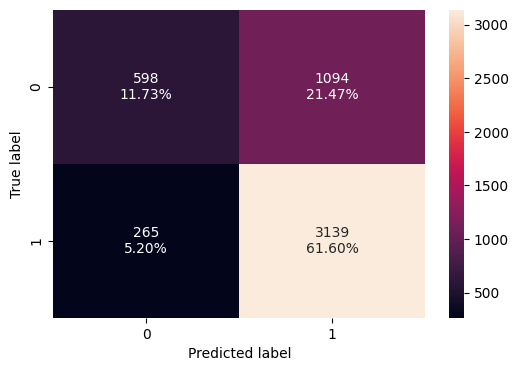

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(gb_tuned2, X_val, y_val)

* Recall has increased to  ~92% as compared to the tuned Adaboost

### Random Forest Classifier

Training performance:
    Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.713   0.833      0.760 0.795


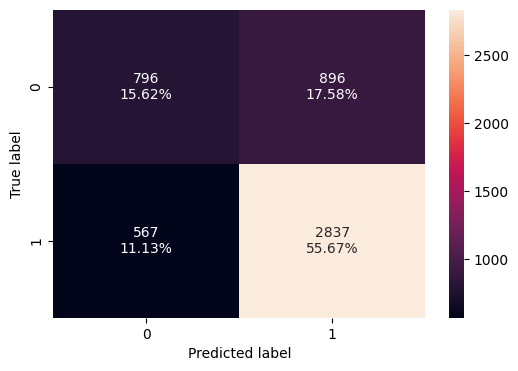

In [ ]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

### Observation
* The model  sufferes overfitting. It shows better performance on training but poor performance in testing

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(class_weight={0:0.18,1:0.82},random_state=1,oob_score=True,bootstrap=True)

parameters = {
                'max_depth': [3,4,7],
                'max_features': ['sqrt','log2'],
                'min_samples_leaf': [2,3],
                'min_samples_split': [2,7,10],
                'n_estimators':[100,150,200,250] }


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.18, 1: 0.82}, max_depth=7,
                       min_samples_leaf=2, oob_score=True, random_state=1)

Training performance:
    Accuracy  Recall  Precision    F1
0     0.676   1.000      0.673 0.805
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.672   0.999      0.671 0.803


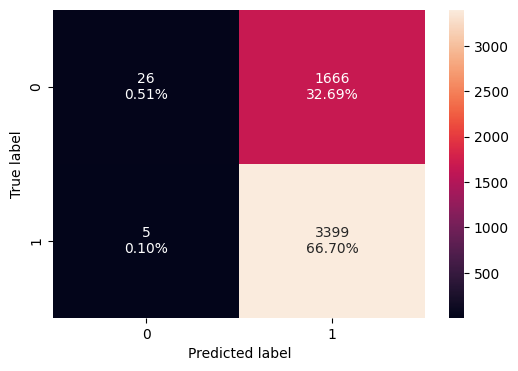

In [ ]:
#Calculating different metrics
rf_tuned_model_train=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train)
rf_tuned_model_val=model_performance_classification_sklearn(rf_tuned,X_val,y_val)
print("Testing performance:\n",rf_tuned_model_val)
#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned,X_val,y_val)

* Randomforest tuned with grid search has better recall value

### Comparing models from GridsearchCV and RandomisedsearchCV

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        adaboost_grid_train.T,
        gboost_grid_train.T,
        gboost_random_train.T,
        rf_tuned_model_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost with Grid search",
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "Random Forest with Grid Search"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost with Grid search,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,Random Forest with Grid Search
Accuracy,0.746,0.726,0.737,0.676
Recall,0.862,0.922,0.928,1.000
Precision,0.781,0.735,0.743,0.673
F1,0.819,0.818,0.825,0.805


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        adaboost_grid_val.T,
        gboost_grid_val.T,
        gboost_random_val.T,
        rf_tuned_model_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "AdaBoost with Grid search",
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "Random Forest with Grid Search"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost with Grid search,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,Random Forest with Grid Search
Accuracy,0.746,0.728,0.733,0.672
Recall,0.857,0.918,0.922,0.999
Precision,0.783,0.738,0.742,0.671
F1,0.818,0.818,0.822,0.803


### Observation
* Gradient Boost Tuned with random search has almost similar value for both Grid search and random search

In [ ]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(gb_tuned1, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.719,0.918,0.731,0.814


* Since the validation and testing shows the similar perfomance value gradient boosting is the best model

#### Feature Importance from Gradient Boost

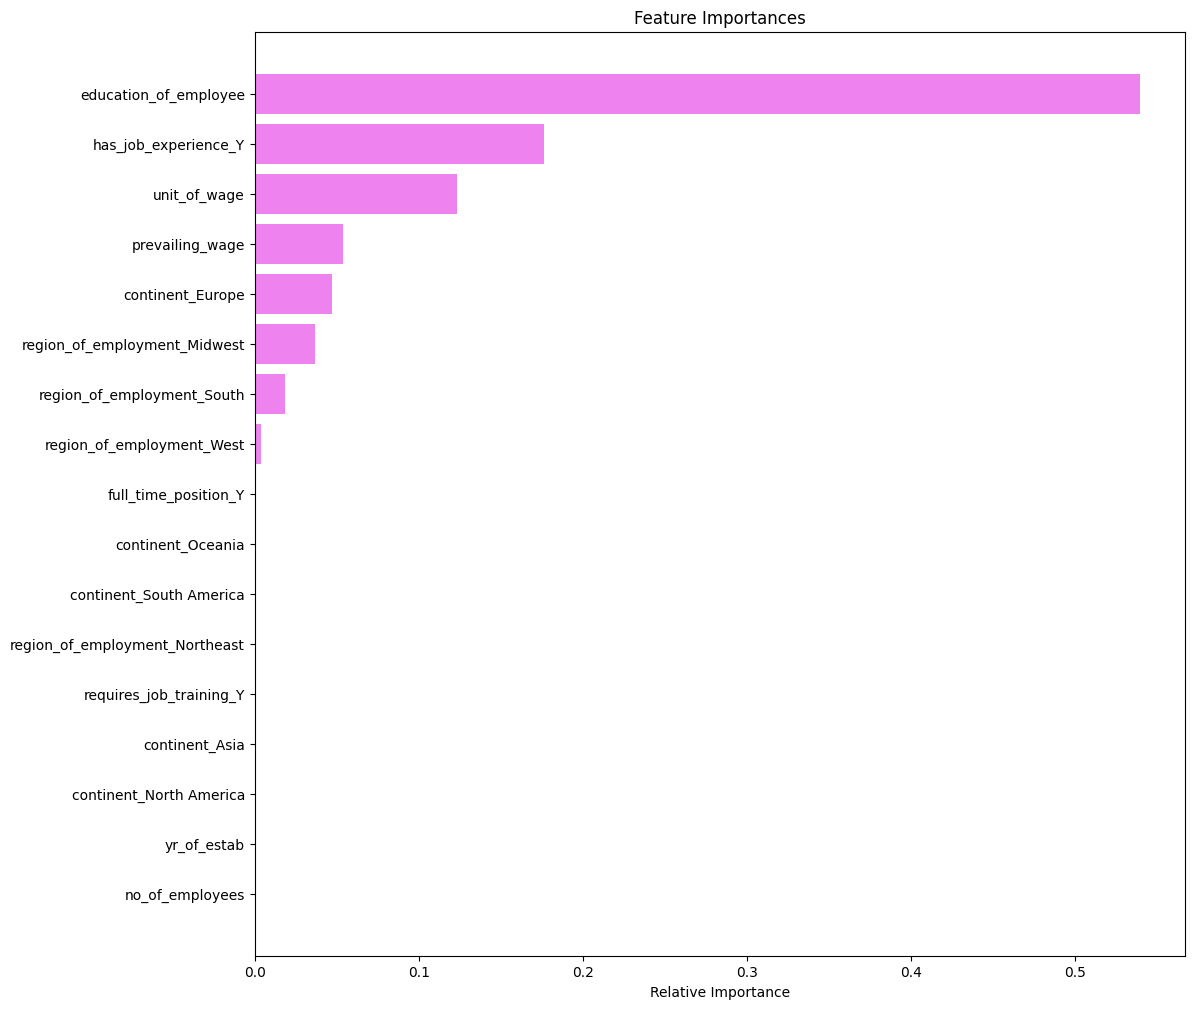

In [ ]:
feature_names = X_train.columns
importances = gb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

*    education_of_employee,has_job_experience_y,unit_of_wage,prevailing_wage,continent Europe which respectively play an important role in Adaboost.

### Feature importance from Adaboost

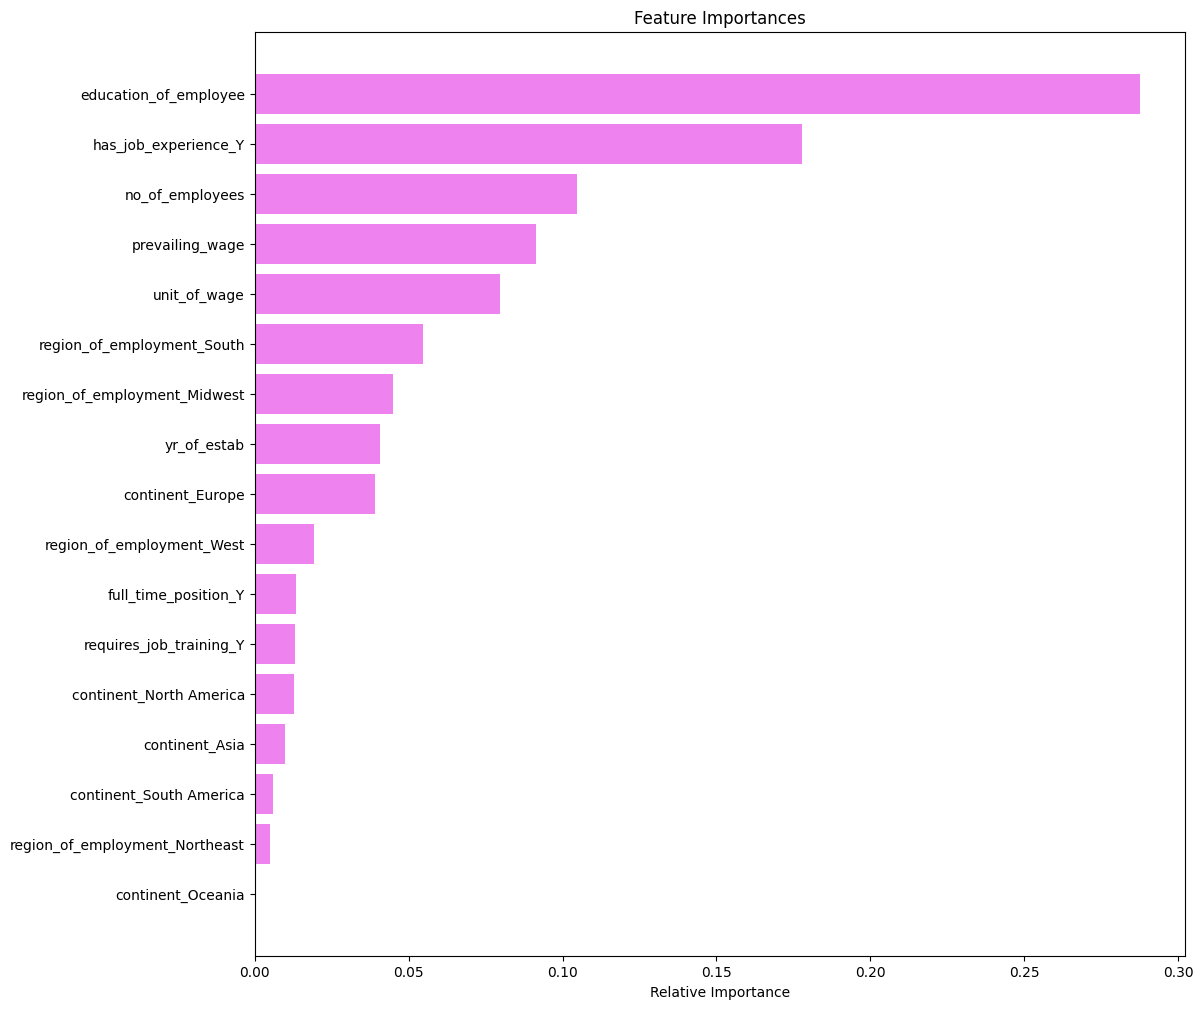

In [ ]:
feature_names = X_train.columns
importances = model_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* educattion of employee,has_job_experience_y,no_employee,prevailing wage are the features of Adaboost

### Conclusion and Insights

* Gradient boosting with hyperparameter tuning has better performance compared to other models.
* Performnace of the model is similar in case of randomsearchCV and gridsearchCV  hyperparameter tuning
* The education_of_employee is the most significant features for the visa approval.
* The unit of wage and has_job_experince are also significant features
* The prevailing wage is also a significant feature
*  Most of the applicants from Europe has got easy visa approval
* Most of the applicants other than Europe has got visa rejection